In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [15]:
data=pd.read_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\Cleaned")
df=pd.DataFrame(data)

In [16]:
X = df.drop(columns=["Target"])
y = df["Target"]

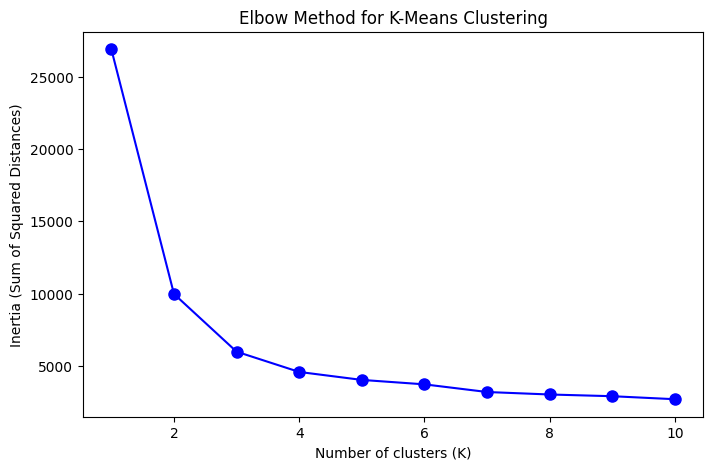

In [17]:
# Elbow method to determine optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # X is already scaled
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method for K-Means Clustering")
plt.show()


In [24]:
optimal_k = 4  # adjust based on elbow curve visually

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)

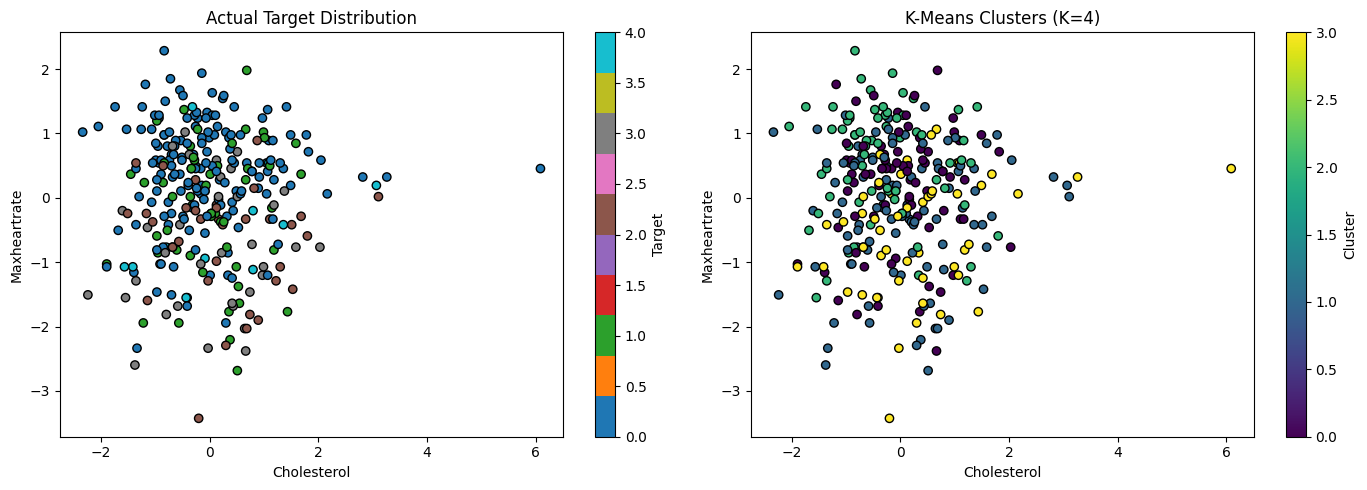

In [25]:
top_features = ['Cholesterol', 'Maxheartrate']  # use your selected features

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual Target
scatter1 = ax[0].scatter(X[top_features[0]], X[top_features[1]], c=y, cmap='tab10', edgecolor='k')
ax[0].set_title("Actual Target Distribution")
ax[0].set_xlabel(top_features[0])
ax[0].set_ylabel(top_features[1])
fig.colorbar(scatter1, ax=ax[0], label="Target")

# Right: KMeans Clusters
scatter2 = ax[1].scatter(X[top_features[0]], X[top_features[1]], c=clusters_kmeans, cmap='viridis', edgecolor='k')
ax[1].set_title(f"K-Means Clusters (K={optimal_k})")
ax[1].set_xlabel(top_features[0])
ax[1].set_ylabel(top_features[1])
fig.colorbar(scatter2, ax=ax[1], label="Cluster")

plt.tight_layout()
plt.show()


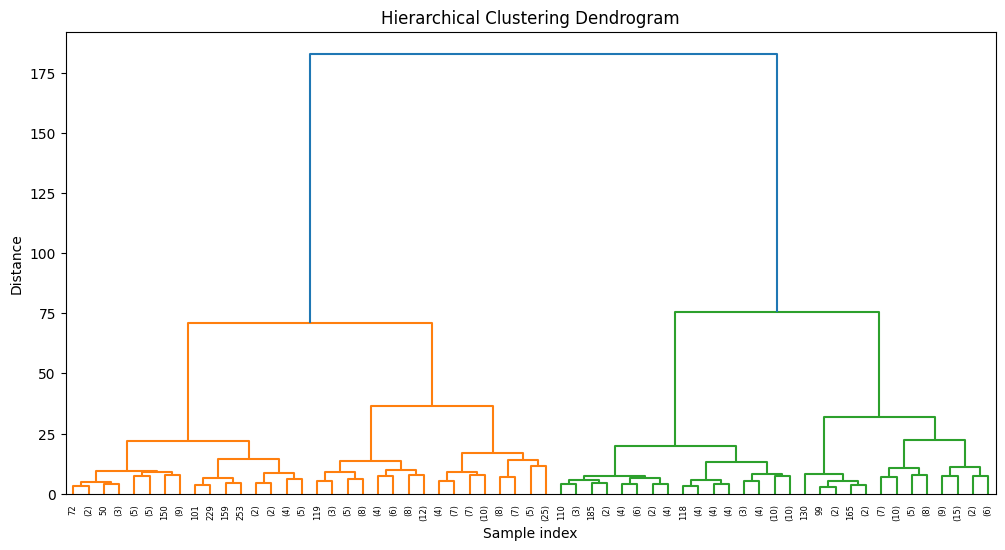

Chosen threshold: 38.11 -> Produced 4 clusters


In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np

# Compute linkage matrix
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

# Automatically find a threshold to get ~4 clusters
target_n_clusters = 4
possible_thresholds = np.linspace(Z[:, 2].min(), Z[:, 2].max(), 50)

best_threshold = None
best_diff = float("inf")
for t in possible_thresholds:
    n_clusters = len(np.unique(fcluster(Z, t=t, criterion='distance')))
    if abs(n_clusters - target_n_clusters) < best_diff:
        best_diff = abs(n_clusters - target_n_clusters)
        best_threshold = t

clusters_hier = fcluster(Z, t=best_threshold, criterion='distance')
print(f"Chosen threshold: {best_threshold:.2f} -> Produced {len(np.unique(clusters_hier))} clusters")


In [11]:

comparison_df = pd.DataFrame({
    "Actual": y,
    "KMeans_Cluster": clusters_kmeans,
    "Hierarchical_Cluster": clusters_hier
})

# Show first few rows
print(comparison_df.head())

# Cross-tab to see correspondence
print("\nK-Means vs Actual:")
print(pd.crosstab(comparison_df["Actual"], comparison_df["KMeans_Cluster"]))

print("\nHierarchical vs Actual:")
print(pd.crosstab(comparison_df["Actual"], comparison_df["Hierarchical_Cluster"]))


   Actual  KMeans_Cluster  Hierarchical_Cluster
0       2               2                     4
1       1               2                     4
2       0               2                     4
3       0               2                     4
4       0               2                     4

K-Means vs Actual:
KMeans_Cluster   0   1   2   3
Actual                        
0               44  36  39  40
1                9  14  18  13
2                6  15   9   5
3               12   7   6  10
4                3   2   4   4

Hierarchical vs Actual:
Hierarchical_Cluster   1   2   3   4
Actual                              
0                     26  39  41  53
1                     12   8  16  18
2                     12   7   6  10
3                      5  10  10  10
4                      2   1   6   4
